# CaSR Outputs vs HRDPS Outputs in March 2023

## Surface Velocity

In [ ]:
# path

path_CaSR_u='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
path_CaSR_v='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'



Maximum longitude difference:
0.03588104248046875
Maximum latitude difference:
0.037761688232421875

Processing 2023-03-02
HRDPS U file: /results2/SalishSea/nowcast-green.202111/02mar23/SalishSea_1h_20230302_20230302_grid_U.nc
HRDPS V file: /results2/SalishSea/nowcast-green.202111/02mar23/SalishSea_1h_20230302_20230302_grid_V.nc
CaSR time steps:  9
HRDPS time steps: 24


ValueError: 2023-03-02: CaSR has 9 time steps, but HRDPS has 24 time steps.

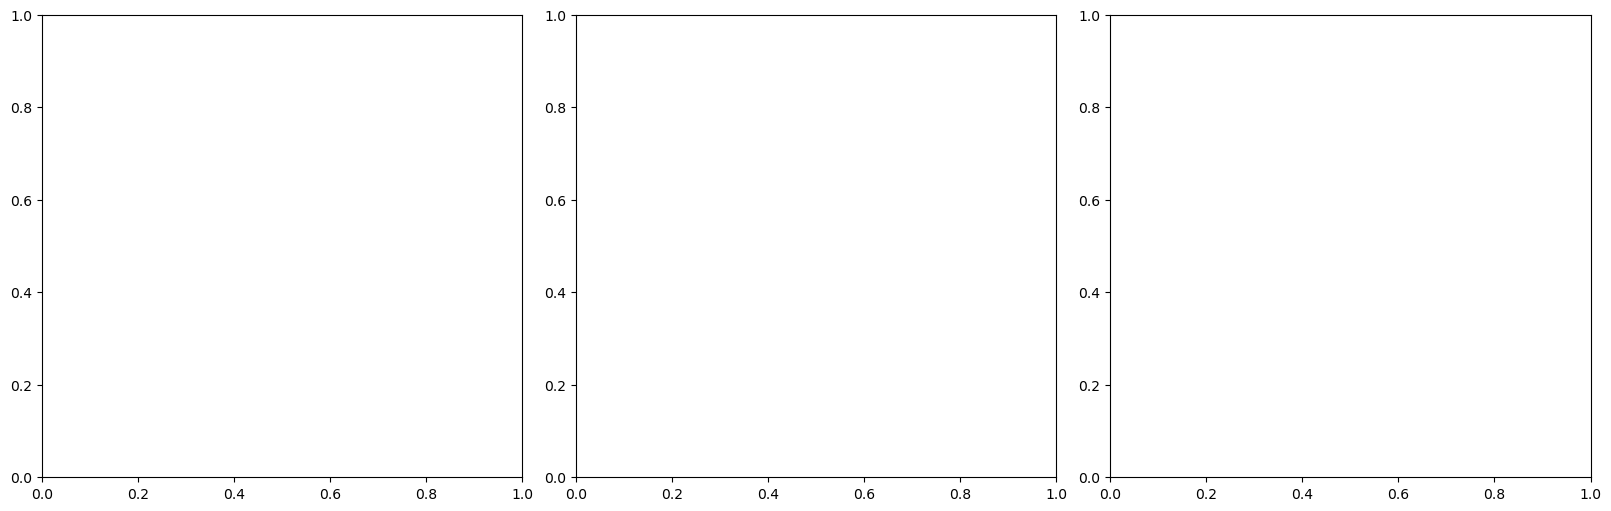

In [1]:
# imports
# --------

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


# CaSR monthly files
# ------------------

path_CaSR_u = (
    "/ocean/jqiu/results/CaSR/00mar23/"
    "SalishSea_1h_20230301_20230331_grid_U.nc"
)

path_CaSR_v = (
    "/ocean/jqiu/results/CaSR/00mar23/"
    "SalishSea_1h_20230301_20230331_grid_V.nc"
)


# Dates to compare
# ----------------

dates = ["2023-03-02", "2023-03-16", "2023-03-31"]


def hrdps_file_path(date_string, grid):
    """
    Construct the HRDPS daily file path.

    Parameters
    ----------
    date_string : str
        Date formatted as YYYY-MM-DD.
    grid : str
        Either "U" or "V".
    """
    date = np.datetime64(date_string)
    compact_date = np.datetime_as_string(date, unit="D").replace("-", "")
    folder_date = compact_date[6:8] + "mar23"

    return (
        f"/results2/SalishSea/nowcast-green.202111/{folder_date}/"
        f"SalishSea_1h_{compact_date}_{compact_date}_grid_{grid}.nc"
    )


# Open CaSR monthly datasets
# --------------------------

ds_CaSR_u = xr.open_dataset(path_CaSR_u)
ds_CaSR_v = xr.open_dataset(path_CaSR_v)

u_CaSR = ds_CaSR_u["vozocrtx"].isel(depthu=0)
v_CaSR = ds_CaSR_v["vomecrty"].isel(depthv=0)


# Check horizontal coordinates
# ----------------------------

lon_u = ds_CaSR_u["nav_lon"]
lat_u = ds_CaSR_u["nav_lat"]

lon_v = ds_CaSR_v["nav_lon"]
lat_v = ds_CaSR_v["nav_lat"]

print("Maximum longitude difference:")
print(float(np.nanmax(np.abs(lon_u.values - lon_v.values))))

print("Maximum latitude difference:")
print(float(np.nanmax(np.abs(lat_u.values - lat_v.values))))


# Create scatter plots
# --------------------

fig, axes = plt.subplots(
    1,
    len(dates),
    figsize=(16, 5),
    constrained_layout=True,
)

rmse_results = {}

for ax, date_string in zip(axes, dates):

    # Select the complete day from the monthly CaSR files.
    # The upper limit is exclusive, so it is set to the next day.
    start_time = np.datetime64(date_string)
    end_time = start_time + np.timedelta64(1, "D")

    u_CaSR_day = u_CaSR.sel(
        time_counter=slice(start_time, end_time - np.timedelta64(1, "ns"))
    )
    v_CaSR_day = v_CaSR.sel(
        time_counter=slice(start_time, end_time - np.timedelta64(1, "ns"))
    )

    # Open corresponding HRDPS daily files
    file_HRDPS_u = hrdps_file_path(date_string, "U")
    file_HRDPS_v = hrdps_file_path(date_string, "V")

    print(f"\nProcessing {date_string}")
    print(f"HRDPS U file: {file_HRDPS_u}")
    print(f"HRDPS V file: {file_HRDPS_v}")

    if not Path(file_HRDPS_u).exists():
        raise FileNotFoundError(file_HRDPS_u)

    if not Path(file_HRDPS_v).exists():
        raise FileNotFoundError(file_HRDPS_v)

    with (
        xr.open_dataset(file_HRDPS_u) as ds_HRDPS_u,
        xr.open_dataset(file_HRDPS_v) as ds_HRDPS_v,
    ):
        u_HRDPS_day = ds_HRDPS_u["vozocrtx"].isel(depthu=0).load()
        v_HRDPS_day = ds_HRDPS_v["vomecrty"].isel(depthv=0).load()

    # Confirm that the expected hourly records were selected
    n_CaSR = u_CaSR_day.sizes["time_counter"]
    n_HRDPS = u_HRDPS_day.sizes["time_counter"]

    print(f"CaSR time steps:  {n_CaSR}")
    print(f"HRDPS time steps: {n_HRDPS}")

    if n_CaSR != n_HRDPS:
        raise ValueError(
            f"{date_string}: CaSR has {n_CaSR} time steps, "
            f"but HRDPS has {n_HRDPS} time steps."
        )

    # Assign the CaSR time coordinates to HRDPS.
    # This avoids alignment problems caused by slightly different
    # time-coordinate definitions in the two model outputs.
    u_HRDPS_day = u_HRDPS_day.assign_coords(
        time_counter=u_CaSR_day.time_counter
    )
    v_HRDPS_day = v_HRDPS_day.assign_coords(
        time_counter=v_CaSR_day.time_counter
    )

    # Calculate surface-current speed
    velocity_CaSR = np.sqrt(u_CaSR_day**2 + v_CaSR_day**2)
    velocity_HRDPS = np.sqrt(u_HRDPS_day**2 + v_HRDPS_day**2)

    # Convert all 24 hours and all grid cells into one-dimensional arrays
    casr = velocity_CaSR.values.ravel()
    hrdps = velocity_HRDPS.values.ravel()

    # Retain locations where both datasets are finite
    valid = np.isfinite(casr) & np.isfinite(hrdps)

    casr_valid = casr[valid]
    hrdps_valid = hrdps[valid]

    if casr_valid.size == 0:
        raise ValueError(f"No valid paired data found for {date_string}.")

    # Statistics
    difference = hrdps_valid - casr_valid

    rmse = np.sqrt(np.mean(difference**2))
    bias = np.mean(difference)
    correlation = np.corrcoef(casr_valid, hrdps_valid)[0, 1]

    rmse_results[date_string] = rmse

    # Scatter plot
    ax.scatter(
        casr_valid,
        hrdps_valid,
        s=3,
        alpha=0.2,
        edgecolors="none",
    )

    # 1:1 line
    lower = 0
    upper = 4

    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.5,
        color="k",
        label="1:1 line",
    )

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(r"CaSR velocity (m s$^{-1}$)")
    ax.set_ylabel(r"HRDPS velocity (m s$^{-1}$)")

    ax.set_title(
        f"{date_string}\n"
        f"RMSE = {rmse:.4f}, bias = {bias:.4f}\n"
        f"r = {correlation:.3f}, N = {casr_valid.size:,}"
    )

    ax.grid(alpha=0.3)
    ax.legend()


fig.suptitle(
    "Surface-current speed comparison: CaSR versus HRDPS",
    fontsize=14,
)

plt.show()


# Print RMSE summary
# ------------------

print("\nRMSE summary")
for date_string, rmse in rmse_results.items():
    print(f"{date_string}: {rmse:.6f} m/s")


# Close monthly datasets
# ----------------------

ds_CaSR_u.close()
ds_CaSR_v.close()